1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.
2. Feature Engineering
3. Divide the dataset into 2 training and test sets
4. Use logistic model Regression. Try to apply different *solver* and *penalty* to find the best one.
5. Perform model on training set and test set
6. Measure performance of the model.
7. Which metric is your main metric and why? Which solver and penalty have you chosen? (<= 100 words)


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable. The final error based on my train and test set is low enough.
3. The data preprocessing is correct or make sense
4. The Feature engineering is correct or make sense
5. Any other additional process will be considered a small plus point.

**Submission Link**: https://forms.gle/M2CxqVGrKLTzqR7g9 (Submit your .ipynb file)

- Age: This is the attribute that describes the age of the patient. There is data type $int64$, the highest value is 29, and the lowest is 77.
- Sex: This is the attribute indicating the gender of the patient, where 0 indicates male patient, 1 female patient.
- ChestPainType: This is the attribute that indicates the patient's chest pain level. With levels 0, 1, 2, and 3.
- RestingBP: This is the attribute that indicates the patient's blood pressure with data type $int64$, the value is in the range [94, 200]
- Cholesterol: This attribute indicates the patient's cholesterol level as measured in the hospital. Has the data type $int64$, where the value is in [126, 564]
- FastingBS: This is an attribute that describes the patient's fasting blood sugar. In which, if the patient has more than 120mg/dl sugar = 1, otherwise = 0.
- RestingECG: This property displays the results of the ECG from 0 to 2 (0, 1, 2). Where each value indicates the severity of the pain.
- thalach: Patient's highest heart rate
- ExerciseAngina: Whether or not you have angina during exercise. Yes denotes 1, no denotes 0.
- Oldpeak: Attribute expressing the stress level of the patient. Has a value of type $float64$, the value is in [0, 6.2]
- ST\_Slope: Patient's condition during exercise. Includes [Upsloping, Flat, Down sloping] states that are sequentially digitized to [0, 1, 2].
- ca: number of major vessels (0-3) colored by flourosopy - given
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
- HeartDisease: Results of the patient's condition. 1 is for signs of heart disease, 0 is for no signs of heart disease.

## Load Dataset

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
PATH = "D:/NMMH/Week 2/heart.csv"

df = pd.read_csv(PATH)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
1,71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
2,71,0,1,160,303,0,1,163,0,0.4,2,2,2,1
3,71,0,1,160,304,0,1,164,0,0.4,2,2,2,1
4,71,0,1,160,305,0,1,165,0,0.4,2,2,2,1


In [13]:
print("Number of rows : {}".format(df.shape[0]))
print("Number of columns : {}".format(df.shape[1]))

Number of rows : 886
Number of columns : 14


## Data Analysis

In [14]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000
mean,54.007901,0.683973,1.005643,132.117381,247.497743,0.168172,0.495485,149.492099,0.310384,1.083296,1.424379,0.714447,2.278781,0.564334
std,9.126292,0.465186,1.024542,16.807511,47.209995,0.374230,0.526669,23.921327,0.462912,1.147935,0.556861,1.028825,0.572576,0.496124
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,212.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,1.000000,130.000000,245.000000,0.000000,0.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,274.000000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,206.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886 entries, 0 to 885
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       886 non-null    int64  
 1   sex       886 non-null    int64  
 2   cp        886 non-null    int64  
 3   trestbps  886 non-null    int64  
 4   chol      886 non-null    int64  
 5   fbs       886 non-null    int64  
 6   restecg   886 non-null    int64  
 7   thalach   886 non-null    int64  
 8   exang     886 non-null    int64  
 9   oldpeak   886 non-null    float64
 10  slope     886 non-null    int64  
 11  ca        886 non-null    int64  
 12  thal      886 non-null    int64  
 13  target    886 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 97.0 KB


In [27]:
print("Continous Columns")
continous_columns = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']]
print(continous_columns.head())

print("Category Columns")
category_columns = df[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']]
print(category_columns.head())

Continous Columns
   age  trestbps  chol  thalach  oldpeak
0   46       120   249      144      0.8
1   71       160   302      162      0.4
2   71       160   303      163      0.4
3   71       160   304      164      0.4
4   71       160   305      165      0.4
Category Columns
   sex  cp  fbs  restecg  exang  slope  ca  thal  target
0    1   0    0        0      0      2   0     3       0
1    0   1    0        1      0      2   2     2       1
2    0   1    0        1      0      2   2     2       1
3    0   1    0        1      0      2   2     2       1
4    0   1    0        1      0      2   2     2       1


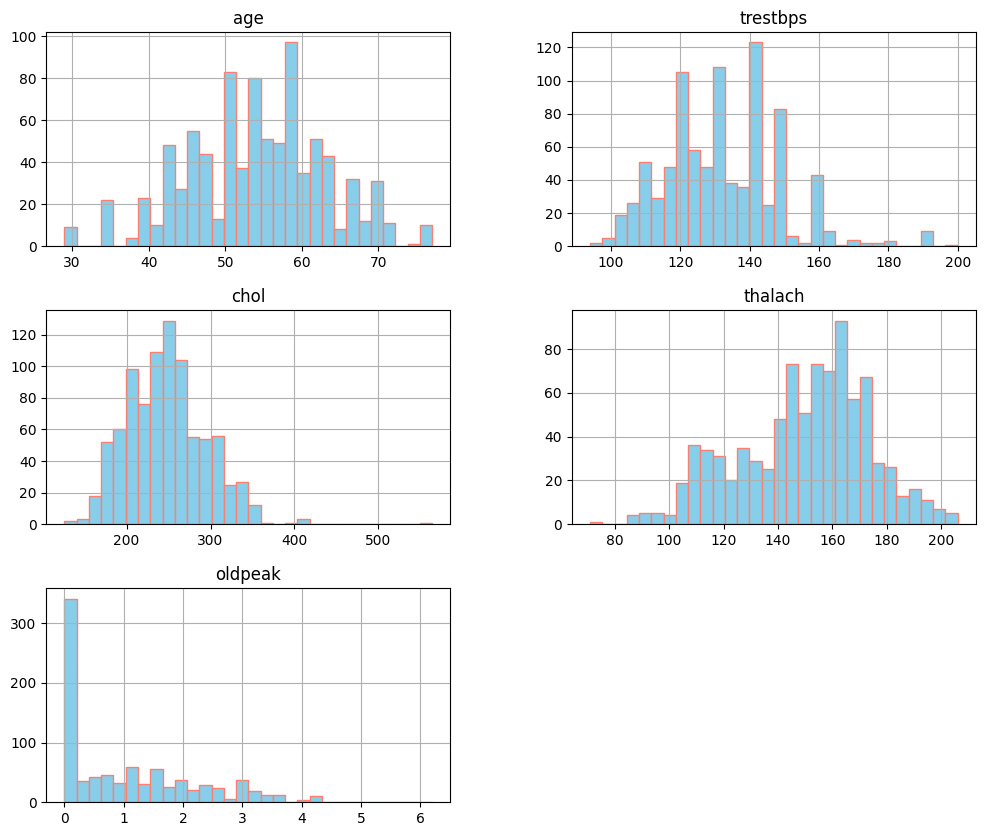

In [75]:
continous_columns.hist(figsize=(12,10), color='skyblue', edgecolor='salmon', bins=30)
plt.show()

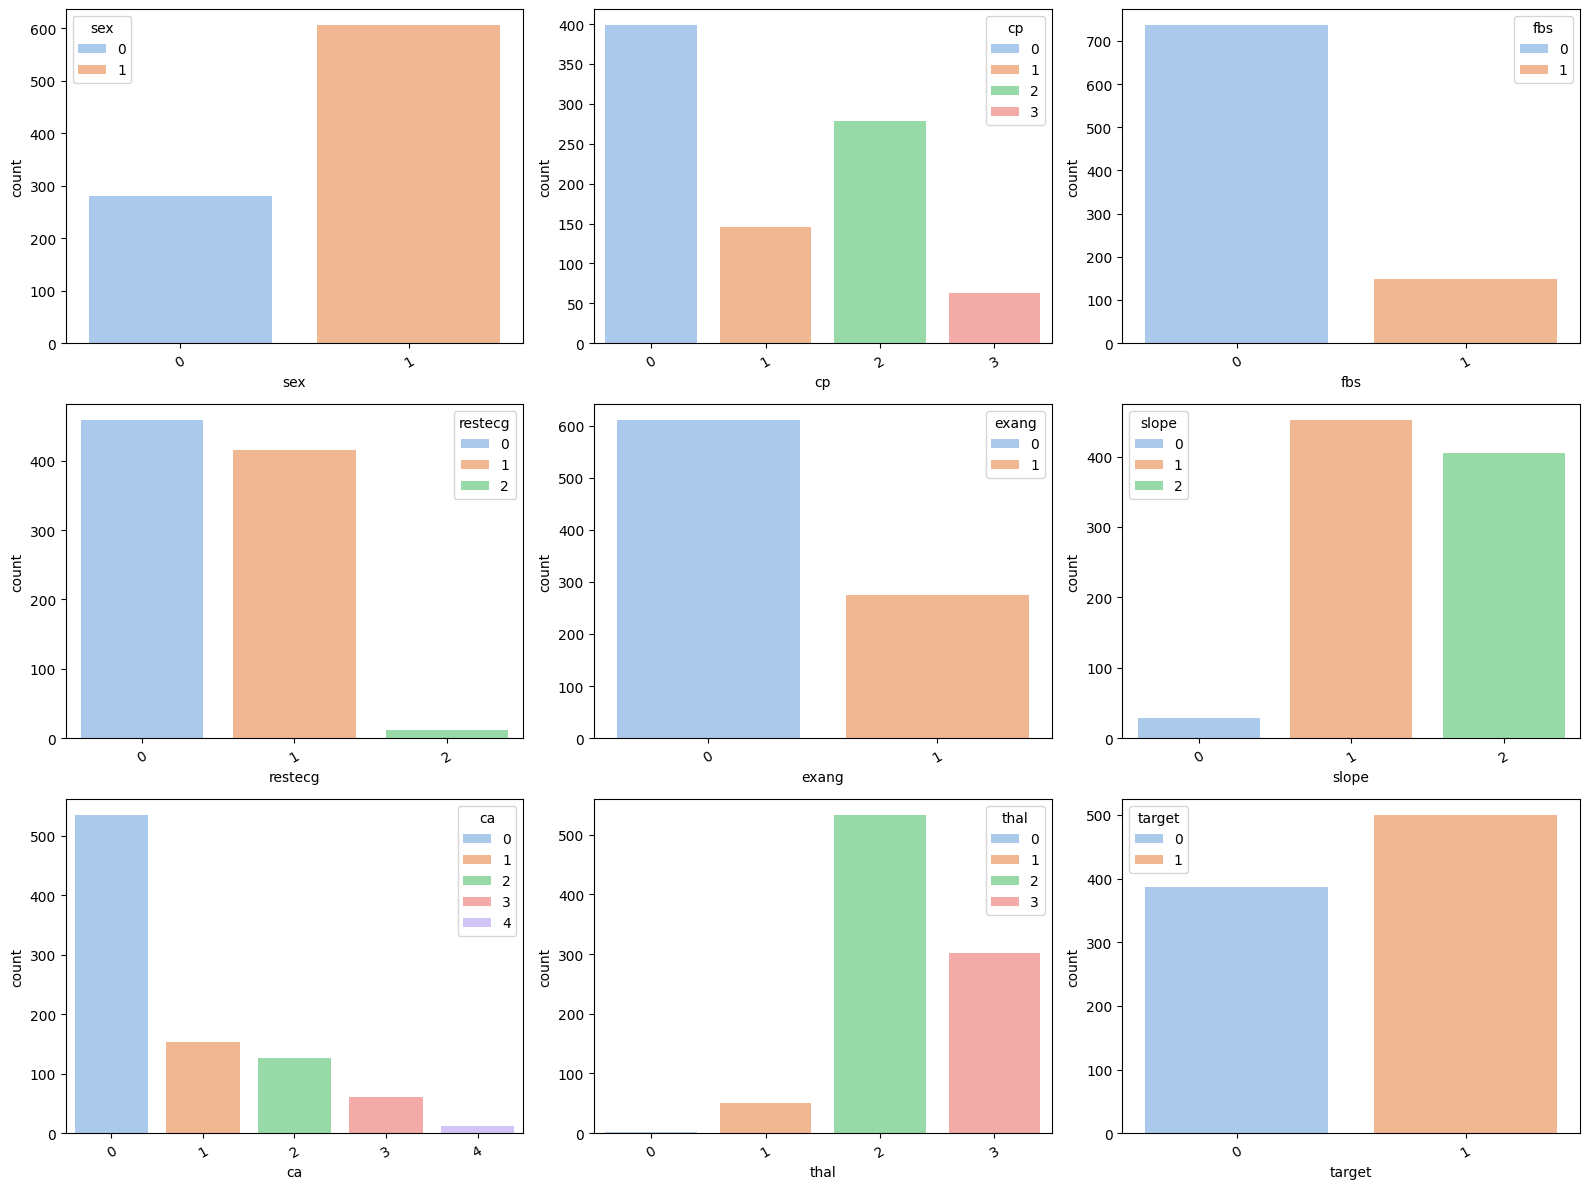

In [49]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(category_columns.columns):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=category_columns, x=col, hue=col, palette="pastel")
    plt.xlabel(col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Preprocessing

In [76]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [ ]:
df_ = df.copy()

## Feature Engineering

<Axes: >

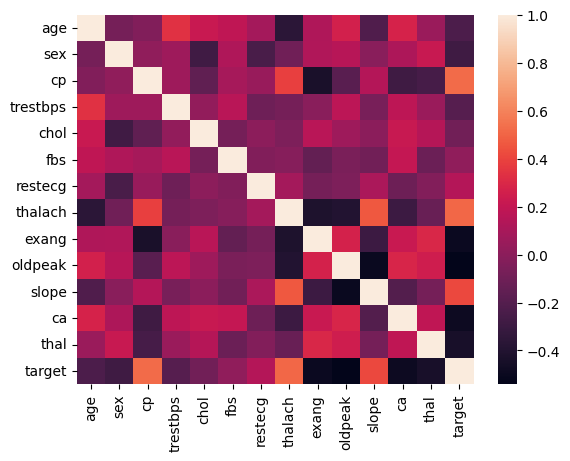

In [84]:
sns.heatmap(df_.corr()) 

In [85]:
def prepare_X_y(df):
    # Todo: Split data into X and y (using sklearn train_test_split). Return two dataframes
    X = df.drop('target', axis=1, inplace=False).values
    y = df['target']
    return X, y

X, y = prepare_X_y(df_)

# Apply machine learning model

## Train-test split

In [86]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 101
TRAIN_SIZE = 0.8

trainX, testX ,trainY, testY = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

## Build SK-learn model

In [97]:
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import mean_absolute_error

def build_model(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """

    # Todo: Input your scaler and logistic model into pipeline
    model = make_pipeline(StandardScaler(), LogisticRegression(penalty='l2', fit_intercept=True, solver='liblinear'))
    # Todo: fit your model with X, y
    model.fit(X,y)

    return model

def calculate_performance(y_true, y_pred):
    """

    :param y_true: ground truth values
    :param y_pred: predictions
    :return:
    """
    # Todo: return your error value like accuracy, f1score, ...
    print("precision :", precision_score(y_true, y_pred))
    print("recall :", recall_score(y_true, y_pred))
    print("accuracy :", accuracy_score(y_true, y_pred))
    print("F1 :", f1_score(y_true, y_pred))
    print("Confusion matrix: \n", confusion_matrix(y_true , y_pred))

    # Todo: Only choose one of them as your score for the question 7
    main_score = f1_score(y_true, y_pred)
    return main_score

model = build_model(trainX, trainY)

In [98]:
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of logistic model on TRAIN set ", mean_absolute_error(y_pred=pred, y_true=trainY))

pred = model.predict(testX)
print("mean absolute error of logistic model on TEST set ", mean_absolute_error(y_pred=pred, y_true=testY))
print()

logistic_F1 = calculate_performance(testY, pred)
print("Main score : ", logistic_F1)
print()

mean absolute error of logistic model on TRAIN set  0.04096045197740113
mean absolute error of logistic model on TEST set  0.06179775280898876

precision : 0.9245283018867925
recall : 0.9702970297029703
accuracy : 0.9382022471910112
F1 : 0.9468599033816425
Confusion matrix: 
 [[69  8]
 [ 3 98]]
Main score :  0.9468599033816425



In [99]:
print(classification_report(testY, pred))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93        77
           1       0.92      0.97      0.95       101

    accuracy                           0.94       178
   macro avg       0.94      0.93      0.94       178
weighted avg       0.94      0.94      0.94       178



In [ ]:
def get_conclusion():
    # Todo: Please return your answer, conclusion and opinion right here
    return "Dùng F1 làm Main Score vì nó là chỉ số dung hòa giữa precision và recall để cân bằng của 2 chỉ số" \
            "F1 có thể được sử dụng cho cả đánh giá theo lớp và tổng thể" \
            "Nếu F1 Score càng cao thì model càng tốt nên F1 score = 0.95 nên model hoạt động rất tốt" \
                \
           "Phân tích confusion matrix : (69+8)=77 trường hợp KHÔNG bệnh và (3+98)=101 trường hợp CÓ bệnh" \
               "69 trường hợp : dự đoán không bệnh, thực tế không bệnh" \
                "8 trường hợp : dự đoán có bệnh, thực tế không bệnh" \
                "3 trường hợp : dự đoán không bệnh, thực tế có bệnh" \
                "98 trường hợp : dự đoán có bệnh, thực tế có bệnh" 